In [ ]:
# 1) Import Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance

In [ ]:
# 2) Load the data
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')



In [ ]:
# 3) Understand the data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

In [ ]:
# 4) Clean the Data
df.drop("customerID", axis=1, inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)


In [ ]:
# 5) Convert text into numbers(Encode Categorical variables)
encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

In [ ]:
# 6) Select input(X) and output(y)
X = df.drop("Churn", axis=1)   # customer details
y = df["Churn"]               # target column


In [ ]:
# 7) Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# 8) Train the model(Class - Weight Balanced)
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# 9) Make Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [ ]:
# 10) Evaluating Model Performance
print("\n--- MODEL PERFORMANCE ---")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


--- MODEL PERFORMANCE ---
Accuracy : 0.736318407960199
Recall   : 0.7994652406417112
ROC-AUC  : 0.8298217641364387

Confusion Matrix:
 [[737 296]
 [ 75 299]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



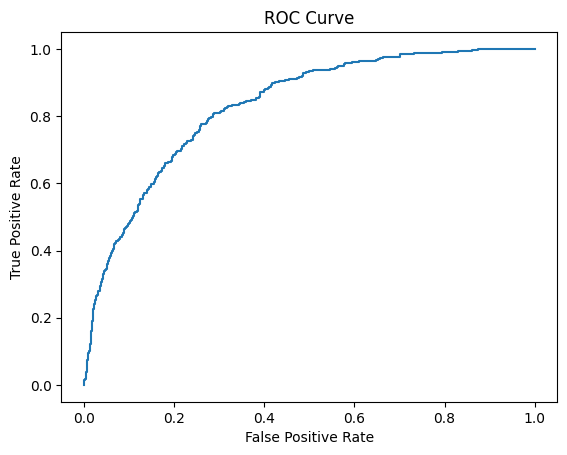

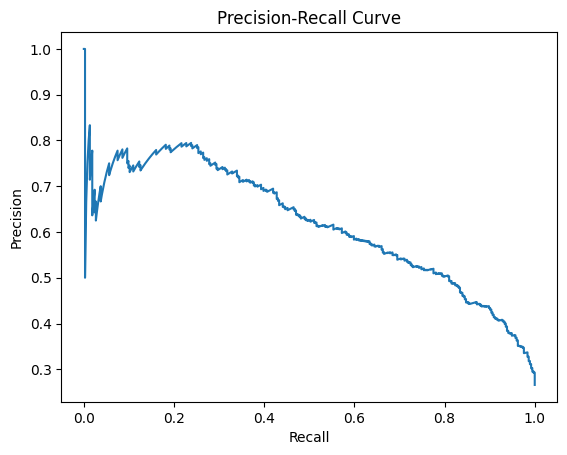

In [ ]:
# 11) CURVES — ROC & PRECISION-RECALL
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [ ]:
# 12) RISK SEGMENTATION (BUSINESS OUTPUT)
results = pd.DataFrame({
    "Churn_Probability": y_prob
})

results["Risk_Level"] = results["Churn_Probability"].apply(
    lambda x: "High" if x > 0.7 else ("Medium" if x > 0.4 else "Low")
)

results.to_csv("customer_churn_risk.csv", index=False)
print("\nSaved: customer_churn_risk.csv")


Saved: customer_churn_risk.csv



--- TOP CHURN DRIVERS ---
            Feature  Importance
4            tenure    0.100995
17   MonthlyCharges    0.032480
18     TotalCharges    0.011230
7   InternetService    0.006894
8    OnlineSecurity    0.006468
14         Contract    0.006041
9      OnlineBackup    0.004762
3        Dependents    0.003412
5      PhoneService    0.003127
16    PaymentMethod    0.001919


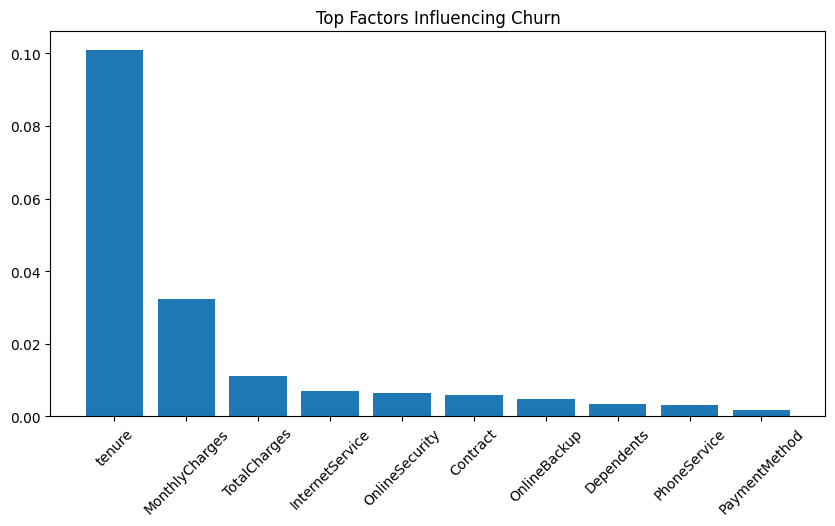

In [ ]:
# 13) FEATURE IMPORTANCE (PERMUTATION)

perm = permutation_importance(model, X_test, y_test, n_repeats=10)

fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\n--- TOP CHURN DRIVERS ---")
print(fi.head(10))

plt.figure(figsize=(10,5))
plt.bar(fi["Feature"][:10], fi["Importance"][:10])
plt.xticks(rotation=45)
plt.title("Top Factors Influencing Churn")
plt.show()

In [ ]:
# 14) RANDOM FOREST BENCHMARK

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n--- RANDOM FOREST COMPARISON ---")
print("RF Recall :", recall_score(y_test, rf_pred))
print("RF ROC-AUC:", roc_auc_score(y_test, rf_pred))


--- RANDOM FOREST COMPARISON ---
RF Recall : 0.4893048128342246
RF ROC-AUC: 0.6957656687598034


In [ ]:
# 15) RESULT
print(results.head())
print(results['Risk_Level'].value_counts())

   Churn_Probability Risk_Level
0           0.015259        Low
1           0.255185        Low
2           0.895317       High
3           0.324505        Low
4           0.552339     Medium
Risk_Level
Low       681
Medium    385
High      341
Name: count, dtype: int64
